# [Lab06] Image Processing 2

Kernel operation (convolution, gradient, blur, median) บนภาพจากกล้อง DJI (1280×720)

## ภาพรวม: แต่ละ section ทำอะไร

| Section | สไลด์ | ทำอะไร | ใจความสำคัญ |
|---|---|---|---|
| 1 | 50 | 2D convolution ด้วย kernel 3×3 (ค่า 1–9) | OpenCV ทำ correlation ต้องพลิก kernel 180° เอง |
| 2 | 51 | print ขนาด output แบบ no padding | ขนาด = n − m + 1 → (718, 1278) |
| 3 | 53 | Zero padding + kernel สุ่ม + วัดเวลา | เติม 0 ทำให้ **ขอบมืดลง** |
| 4 | 54 | Same (replicate) padding | ขอบใกล้ค่าเดิม ต่างจาก zero เฉพาะริมภาพ |
| 5 | 62–63 | Sobel → gradient magnitude \|G\| | ขอบ (edge) = พิกเซลที่ gradient สูง |
| 6 | 64 | Box blur: kernel 1 เทียบ 1/9 | ผลรวม kernel ต้อง = 1 ไม่งั้นภาพสว่างเกิน |
| 7 | 65 | Gaussian blur 3×3 / 5×5 + กราฟ | น้ำหนักตรงกลางมากสุด เบลอน้อยกว่า box ขนาดเดียวกัน |
| 8 | 66 | Median filter 5×5 | **ไม่ใช่การเฉลี่ย** (sort แล้วเลือกตัวกลาง) กรอง salt & pepper |

## วิธีอ่านโน้ตบุ๊กนี้

- เซลล์ markdown = คำอธิบาย, เซลล์โค้ด = สิ่งที่ทำจริง (ควรรัน **จากบนลงล่าง** เพราะเซลล์ต่อๆ ไปใช้ตัวแปรและฟังก์ชันจากเซลล์ก่อนหน้า)
- `gray` = ภาพขาวดำช่วง 0–255 (ใช้ section 1–4), `gray01` = ช่วง 0–1 (ใช้ section 5–8)
- `conv_replicate_pad` (ฟังก์ชันใน section 4) ใช้ต่อใน section 5–8 ต้องรันเซลล์นั้นก่อน
- ทุก convolution ใช้ API ของ OpenCV: `cv2.copyMakeBorder` (เติมขอบ) + `cv2.filter2D` (convolve) สรุปไว้ท้ายโน้ตบุ๊ก

## 0. โหลดรูปและแสดงผล

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_PATH = "capture_004_20260916_130133.jpg"
TARGET_SIZE = (1280, 720)  # (width, height)

img_bgr = cv2.imread(IMG_PATH)  # OpenCV โหลดเป็น BGR
assert img_bgr is not None, f"เปิดไฟล์ไม่ได้: {IMG_PATH}"

if (img_bgr.shape[1], img_bgr.shape[0]) != TARGET_SIZE:
    img_bgr = cv2.resize(img_bgr, TARGET_SIZE, interpolation=cv2.INTER_AREA)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # matplotlib ต้องการ RGB
print("shape (rows, cols, channels):", img_rgb.shape, "| dtype:", img_rgb.dtype)

shape (rows, cols, channels): (720, 1280, 3) | dtype: uint8


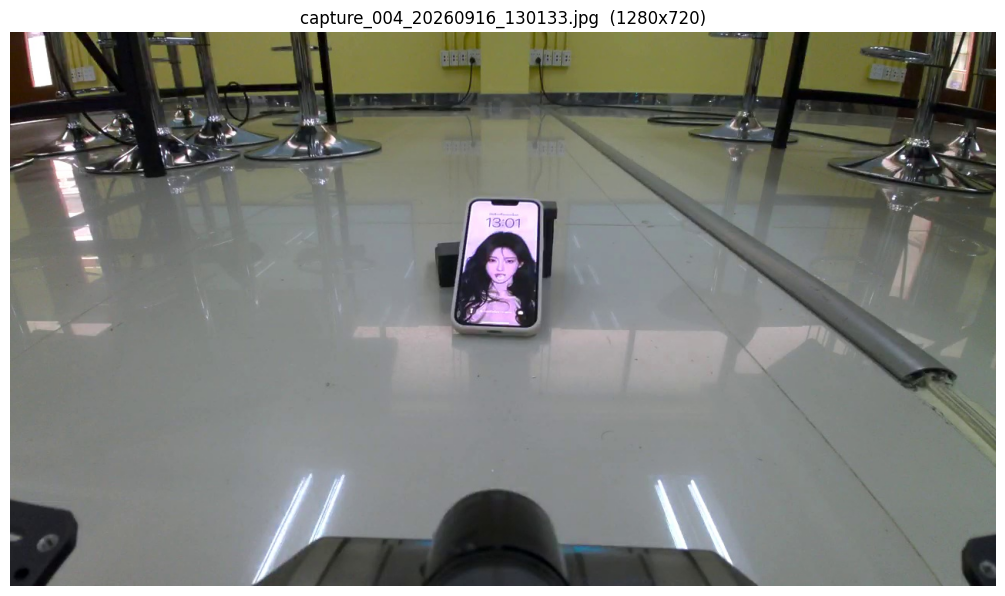

In [2]:
plt.figure(figsize=(12.8, 7.2))
plt.imshow(img_rgb)
plt.title(f"{IMG_PATH}  ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})")
plt.axis("off")
plt.show()

## 1. 2D Convolution (สไลด์ 50)

C = A ∗ H โดย A คือภาพ grayscale และ H คือ kernel 3×3 ที่สร้างเอง (1–9 ตามสไลด์)

- ใช้ OpenCV (`cv2.filter2D`) แต่ต้องพลิก kernel 180° เอง เพราะ OpenCV ทำ correlation
- ตรวจผลด้วยการคำนวณมือที่ตำแหน่ง C[2,2]

In [3]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)   # 1 ช่อง, float กัน overflow

# Kernel H ขนาด m x m (สไลด์หน้า 50 ใช้ 1..9)
m = 3
H = np.arange(1, m * m + 1, dtype=np.float32).reshape(m, m)
# ลองสุ่มแทน: H = np.random.randint(-5, 6, (m, m)).astype(np.float32)

print("gray shape:", gray.shape)
print("H =\n", H)

gray shape: (720, 1280)
H =
 [[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]


### convolution ทำงานยังไง (อ่านก่อนดูเซลล์ถัดไป)

1. วาง kernel 3×3 ทับพิกเซล 3×3 ก้อนหนึ่งของภาพ
2. **คูณ** ค่าที่ตรงช่องกัน แล้ว **บวก** ทั้ง 9 ตัว → ได้ตัวเลขเดียว = พิกเซลของภาพผลลัพธ์ 1 จุด
3. เลื่อน kernel ไปทีละ 1 พิกเซล ทำซ้ำจนทั่วภาพ

**ทำไมต้องพลิก kernel:** สูตรสไลด์คือ `(i·1)+(h·2)+…+(a·9)` คือพิกเซลมุมบนซ้ายของก้อน (a) ไปคูณกับ 9 (มุมล่างขวาของ kernel) เหมือน kernel กลับหัว
แต่ `cv2.filter2D` ไม่พลิกให้ (เรียกว่า correlation) เราจึงพลิกเองด้วย `np.flip` ก่อนส่งเข้าไป

**ขอบภาพ:** `cv2.filter2D` เติมขอบให้เองแบบสะท้อนภาพ ผลจึงได้ขนาดเท่า input (720, 1280) ตัวเลขที่ตรวจมือด้านล่างเป็นตำแหน่งที่ kernel อยู่ในภาพทั้งก้อน จึงไม่โดนผลของขอบ

In [4]:
# cv2.filter2D ทำ correlation (ไม่พลิก kernel) -> พลิก kernel 180 องศาเอง ให้เป็น convolution ตามสไลด์
H_flipped = np.flip(H)   # พลิกทั้งแถวและคอลัมน์

# C = A * H  (cv2 padding ขอบให้เอง ผลจึงมีขนาดเท่า input)
full = cv2.filter2D(gray, cv2.CV_32F, H_flipped)
print("full size:", full.shape)

full size: (720, 1280)


In [5]:
# ตรวจด้วยมือ: patch 3x3 มุมบนซ้าย (ตรงกับ C[2,2] ในสไลด์ ซึ่งนับจาก 1 = full[1, 1])
patch = gray[0:m, 0:m]
manual = np.sum(patch * H_flipped)   # (i·1)+(h·2)+(g·3)+... เพราะ kernel ถูกพลิกแล้ว

print("patch A[0:3, 0:3]:\n", patch)
print("manual  :", manual)
print("cv2     :", full[1, 1])
print("ตรงกัน  :", np.isclose(manual, full[1, 1]))

patch A[0:3, 0:3]:
 [[32. 34. 33.]
 [32. 33. 32.]
 [32. 32. 31.]]
manual  : 1467.0
cv2     : 1467.0
ตรงกัน  : True


## 2. Valid Result (สไลด์ 51) — print output size แบบ no padding

ขนาดผลลัพธ์ = input − kernel + 1 = n − m + 1 (แยกคิดแถวและคอลัมน์ เพราะรูปไม่ใช่สี่เหลี่ยมจัตุรัส)

In [6]:
# no padding: ตัดขอบที่ cv2 เติมให้ออก เหลือเฉพาะตำแหน่งที่ kernel อยู่ในภาพทั้งก้อน
r = m // 2   # ขอบที่ kernel ยื่นออกไป (m=3 -> 1 พิกเซล)
valid = full[r:-r, r:-r]

n_rows, n_cols = gray.shape
print("input  size :", gray.shape)
print("kernel size :", H.shape)
print("output size :", valid.shape)
print("คาดตามสูตร  :", (n_rows - m + 1, n_cols - m + 1), "  (n - m + 1)")

input  size : (720, 1280)
kernel size : (3, 3)
output size : (718, 1278)
คาดตามสูตร  : (718, 1278)   (n - m + 1)


### อ่านผล section 2

- output = **(718, 1278)** = (720 − 3 + 1, 1280 − 3 + 1) ตรงกับสูตร n − m + 1 ที่คิดแยกแถวและคอลัมน์
- ภาพเล็กลงข้างละ 1 พิกเซล เพราะ kernel 3×3 วางได้เฉพาะตำแหน่งที่อยู่ในภาพทั้งก้อน (พิกเซลริมสุดไม่มีเพื่อนบ้านครบ)
- ถ้า convolve หลายรอบภาพจะเล็กลงเรื่อยๆ → จึงต้องมี **padding** (section 3–4) เพื่อรักษาขนาดไว้

## 3. Zero Padding + Convolution (สไลด์ 53)

เติมขอบ 0 รอบภาพก่อน convolve ด้วย kernel สุ่ม (ผลรวม = 1)

- `cv2.copyMakeBorder(..., BORDER_CONSTANT, value=0)` เติมขอบ 0 เอง (ค่าเริ่มต้นของ `filter2D` เป็นแบบสะท้อนภาพ ไม่ใช่ 0)
- p = 1 ชั้น: output ขนาดเท่า input, p = 2 ชั้น: output ใหญ่กว่า input
- ขนาด output = n + 2p − m + 1
- วัดเวลาเฉลี่ยต่อรอบเป็นวินาที

In [7]:
rng = np.random.default_rng(42)          # seed คงที่ ผลซ้ำได้ทุกครั้ง
H_rand = rng.random((m, m)).astype(np.float32)
H_rand /= H_rand.sum()                   # ผลรวม = 1 ภาพไม่สว่าง/มืดเกินช่วง 0-255
H_rand_flipped = np.flip(H_rand)         # พลิก 180 องศา ให้เป็น convolution เหมือนเดิม

print("H_rand =\n", H_rand)
print("sum    =", H_rand.sum())

H_rand =
 [[0.14036408 0.07959466 0.15571468]
 [0.12647414 0.01707993 0.17693813]
 [0.13803972 0.14256003 0.02323459]]
sum    = 1.0


In [8]:
import time


def conv_zero_pad(img, kernel_flipped, p):
    """เติมขอบ 0 หนา p พิกเซล -> convolve -> ตัดขอบที่ cv2 เติมเองทิ้ง (valid บนภาพที่เติมแล้ว)"""
    padded = cv2.copyMakeBorder(img, p, p, p, p, cv2.BORDER_CONSTANT, value=0)
    full = cv2.filter2D(padded, cv2.CV_32F, kernel_flipped)
    r = kernel_flipped.shape[0] // 2
    return padded, full[r:-r, r:-r]


N_RUNS = 20
for p in (1, 2):
    conv_zero_pad(gray, H_rand_flipped, p)   # warm-up: รอบแรกช้ากว่าปกติ

    t0 = time.perf_counter()
    for _ in range(N_RUNS):
        padded, out = conv_zero_pad(gray, H_rand_flipped, p)
    dt = (time.perf_counter() - t0) / N_RUNS   # เวลาเฉลี่ยต่อรอบ (วินาที)

    print(f"p={p} | padded {padded.shape} -> output {out.shape} "
          f"| คาดตามสูตร ({n_rows + 2*p - m + 1}, {n_cols + 2*p - m + 1})")
    print(f"      เวลาเฉลี่ย {dt:.6f} s ({dt*1000:.2f} ms) ต่อรอบ ({N_RUNS} รอบ)")

p=1 | padded (722, 1282) -> output (720, 1280) | คาดตามสูตร (720, 1280)
      เวลาเฉลี่ย 0.004244 s (4.24 ms) ต่อรอบ (20 รอบ)
p=2 | padded (724, 1284) -> output (722, 1282) | คาดตามสูตร (722, 1282)
      เวลาเฉลี่ย 0.003576 s (3.58 ms) ต่อรอบ (20 รอบ)


padded[0:3, 0:3] (แถว/คอลัมน์แรกเป็น 0):
 [[ 0.  0.  0.]
 [ 0. 32. 34.]
 [ 0. 32. 33.]]
manual: 12.0257225 | cv2: 12.0257225 | ตรงกัน: True


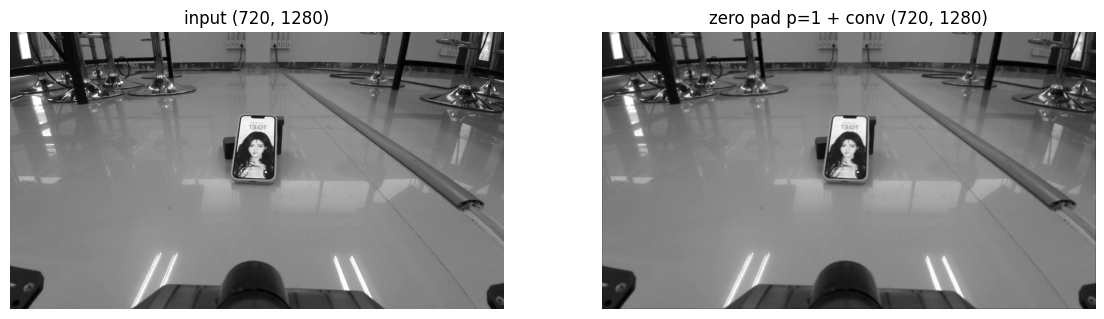

In [9]:
# ตรวจ zero padding ด้วยมือ (p=1): พิกเซลมุมบนซ้ายของผลลัพธ์ โดน kernel ทับขอบที่เป็น 0
padded1, out1 = conv_zero_pad(gray, H_rand_flipped, 1)
manual = np.sum(padded1[0:m, 0:m] * H_rand_flipped)
print("padded[0:3, 0:3] (แถว/คอลัมน์แรกเป็น 0):\n", padded1[0:m, 0:m])
print("manual:", manual, "| cv2:", out1[0, 0], "| ตรงกัน:", np.isclose(manual, out1[0, 0]))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(gray, cmap="gray", vmin=0, vmax=255)
ax[0].set_title(f"input {gray.shape}")
ax[1].imshow(out1, cmap="gray", vmin=0, vmax=255)
ax[1].set_title(f"zero pad p=1 + conv {out1.shape}")
for a in ax:
    a.axis("off")
plt.show()

### อ่านผล section 3 (Zero padding)

- ฟังก์ชัน `conv_zero_pad` ทำ 3 ขั้น: เติมขอบ 0 หนา p พิกเซล → convolve → ตัดขอบที่ cv2 เติมเองทิ้ง (เหลือ output ขนาด n + 2p − m + 1)
- p = 1 → output ขนาดเท่า input (720, 1280), p = 2 → ใหญ่กว่า input ข้างละ 1 พิกเซล
- ตรวจมือที่มุมบนซ้าย: patch แถวและคอลัมน์แรกเป็น **0** จริง ผลจึงต่ำกว่าพิกเซลเดิมมาก (ประมาณ 12 เทียบกับ 32) → ขอบภาพ **มืดลง** เพราะเอา 0 มาถ่วงน้ำหนัก
- kernel สุ่มถูกหารด้วยผลรวมให้ = 1 เพื่อไม่ให้ภาพสว่าง/มืดเกินช่วง
- เวลาอยู่ในหลัก ms เพราะ `filter2D` เป็นโค้ด C++ ความต่างของ p = 1 กับ 2 เป็นแค่ความคลาดเคลื่อนของการวัด

## 4. Same (Replicated) Padding + Convolution (สไลด์ 54)

เหมือน section 3 ทุกอย่าง (kernel สุ่มตัวเดิม, p = 1 และ 2, วัดเวลา) เปลี่ยนแค่การเติมขอบเป็น **ทำซ้ำค่าพิกเซลริมภาพ**

- `cv2.copyMakeBorder(..., BORDER_REPLICATE)`
- ขนาด output ยังเป็น n + 2p − m + 1 เท่า zero padding
- ค่าต่างกันเฉพาะพิกเซลริมภาพ ที่ kernel ทับขอบที่เติม

In [10]:
def conv_replicate_pad(img, kernel_flipped, p):
    """ทำซ้ำค่าขอบหนา p พิกเซล -> convolve -> ตัดขอบที่ cv2 เติมเองทิ้ง (valid บนภาพที่เติมแล้ว)"""
    padded = cv2.copyMakeBorder(img, p, p, p, p, cv2.BORDER_REPLICATE)
    full = cv2.filter2D(padded, cv2.CV_32F, kernel_flipped)
    r = kernel_flipped.shape[0] // 2
    return padded, full[r:-r, r:-r]


for p in (1, 2):
    conv_replicate_pad(gray, H_rand_flipped, p)   # warm-up

    t0 = time.perf_counter()
    for _ in range(N_RUNS):
        padded, out = conv_replicate_pad(gray, H_rand_flipped, p)
    dt = (time.perf_counter() - t0) / N_RUNS   # เวลาเฉลี่ยต่อรอบ (วินาที)

    print(f"p={p} | padded {padded.shape} -> output {out.shape} "
          f"| คาดตามสูตร ({n_rows + 2*p - m + 1}, {n_cols + 2*p - m + 1})")
    print(f"      เวลาเฉลี่ย {dt:.6f} s ({dt*1000:.2f} ms) ต่อรอบ ({N_RUNS} รอบ)")

p=1 | padded (722, 1282) -> output (720, 1280) | คาดตามสูตร (720, 1280)
      เวลาเฉลี่ย 0.003748 s (3.75 ms) ต่อรอบ (20 รอบ)
p=2 | padded (724, 1284) -> output (722, 1282) | คาดตามสูตร (722, 1282)
      เวลาเฉลี่ย 0.003352 s (3.35 ms) ต่อรอบ (20 รอบ)


padded[0:3, 0:3] (แถว/คอลัมน์แรกซ้ำกับพิกเซลริมภาพ):
 [[32. 32. 34.]
 [32. 32. 34.]
 [32. 32. 33.]]
manual: 32.66939 | cv2: 32.66939 | ตรงกัน: True
zero pad  [0,0]: 12.0257225
same pad  [0,0]: 32.66939
พิกเซลที่ต่างกัน: 3996 จุด (ขอบรอบภาพ = 3996 จุด)
ต่างกันในภาพ (ไม่รวมขอบ 1 พิกเซล) max: 0.0


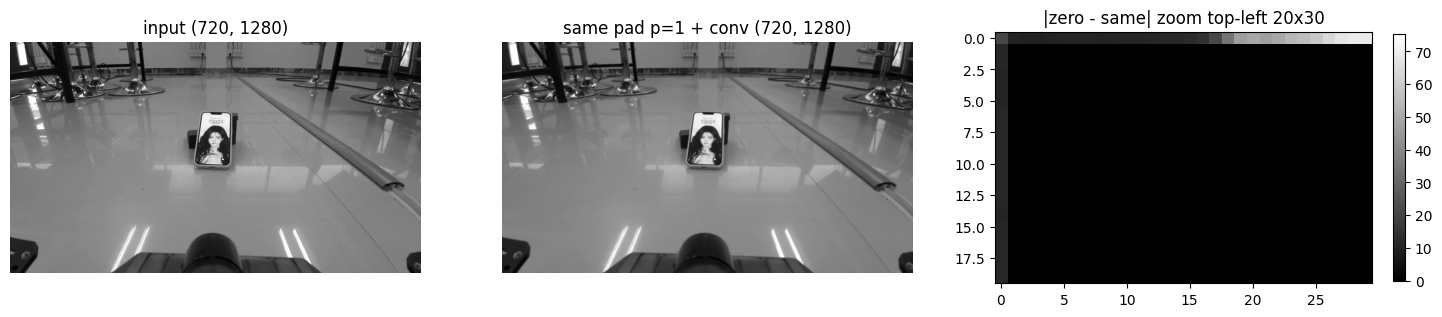

In [11]:
# ตรวจ same padding ด้วยมือ (p=1): พิกเซลมุมบนซ้าย kernel ทับขอบที่ทำซ้ำมาจากพิกเซลริมภาพ
padded1_rep, out1_rep = conv_replicate_pad(gray, H_rand_flipped, 1)
manual = np.sum(padded1_rep[0:m, 0:m] * H_rand_flipped)
print("padded[0:3, 0:3] (แถว/คอลัมน์แรกซ้ำกับพิกเซลริมภาพ):\n", padded1_rep[0:m, 0:m])
print("manual:", manual, "| cv2:", out1_rep[0, 0], "| ตรงกัน:", np.isclose(manual, out1_rep[0, 0]))

# เทียบกับ zero padding (p=1): ต่างกันเฉพาะแถว/คอลัมน์ริมนอกสุด ส่วนในภาพเท่ากัน
diff = np.abs(out1 - out1_rep)
print("zero pad  [0,0]:", out1[0, 0])
print("same pad  [0,0]:", out1_rep[0, 0])
print("พิกเซลที่ต่างกัน:", int((diff > 0).sum()), "จุด (ขอบรอบภาพ =", 2 * (n_rows + n_cols) - 4, "จุด)")
print("ต่างกันในภาพ (ไม่รวมขอบ 1 พิกเซล) max:", diff[1:-1, 1:-1].max())

# ความต่างมีแค่ขอบหนา 1 พิกเซล ภาพเต็มมองไม่เห็น -> ซูมมุมบนซ้าย 20x30 พิกเซล
CROP_R, CROP_C = 20, 30
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].imshow(gray, cmap="gray", vmin=0, vmax=255)
ax[0].set_title(f"input {gray.shape}")
ax[1].imshow(out1_rep, cmap="gray", vmin=0, vmax=255)
ax[1].set_title(f"same pad p=1 + conv {out1_rep.shape}")
im = ax[2].imshow(diff[:CROP_R, :CROP_C], cmap="gray", interpolation="nearest",
                  vmin=0, vmax=diff.max())
ax[2].set_title(f"|zero - same| zoom top-left {CROP_R}x{CROP_C}")
fig.colorbar(im, ax=ax[2], fraction=0.03)
for a in ax[:2]:
    a.axis("off")
plt.show()

### อ่านผล section 4 (Same padding เทียบ zero padding)

- Same padding เติมขอบด้วย **ค่าซ้ำจากพิกเซลริมภาพ** ที่มุมบนซ้ายได้ ~32.7 ใกล้ค่าเดิม 32 ส่วน zero padding ได้ ~12.0 (ขอบมืดลง)
- ต่างกันเฉพาะ **ขอบรอบภาพ** 3,996 จุด ในภาพส่วนที่เหลือต่างกัน 0 เพราะ kernel ไม่ได้ทับช่องที่เติม
- ภาพที่ 3 (|zero − same|) เป็นสีดำเกือบทั้งภาพ = ไม่ต่างกัน ความต่างมีแค่ขอบหนา 1 พิกเซล จึงซูมมุมบนซ้ายให้เห็น (สว่าง = ต่างมาก)
- จากนี้ไปเราใช้ **same padding** เพราะไม่สร้างขอบมืด/ขอบปลอมที่ริมภาพ

## 5. Gradient Magnitude Image (สไลด์ 62–63)

1. **แปลง RGB → Grayscale [0,1]:** ใช้ `cv2.cvtColor` แล้วหารด้วย 255
2. **Sobel 3×3:** Gx = A ∗ Sₓ (ขอบแนวตั้ง), Gy = A ∗ Sᵧ (ขอบแนวนอน) ใช้ same padding
3. **Gradient magnitude:** |G| = √(Gx² + Gy²) แล้ว rescale เป็น [0,1] ด้วย (G − min) / (max − min)

Gradient คือความเร็วที่ความสว่างเปลี่ยนระหว่างพิกเซลข้างเคียง ขอบ (edge) คือพิกเซลที่ gradient สูง

In [12]:
# แปลง BGR -> Grayscale ด้วย API ของ OpenCV แล้วหาร 255 ให้อยู่ในช่วง [0, 1]
gray01 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

print("gray01 shape:", gray01.shape, "| dtype:", gray01.dtype)
print("min/max:", gray01.min(), gray01.max())

gray01 shape: (720, 1280) | dtype: float32
min/max: 0.0 1.0


### Sobel ทำงานยังไง (อ่านก่อนดูเซลล์ถัดไป)

- **Gradient** = ความเร็วที่ความสว่างเปลี่ยนระหว่างพิกเซลข้างเคียง พื้นเรียบ ≈ 0 ส่วนขอบ (สว่างเปลี่ยนแรง) สูง
- **Sₓ** เทียบซ้าย↔ขวา (คอลัมน์ซ้าย +, คอลัมน์ขวา −) จับขอบแนวตั้ง, **Sᵧ** เทียบบน↔ล่าง จับขอบแนวนอน
- ผลรวมของแต่ละ kernel = 0 → พื้นที่ที่พิกเซลเท่ากันหมดได้ 0 พอดี (ต่างจาก blur ที่ผลรวม = 1)
- ใช้ **same padding** เพราะ zero padding จะทำให้ขอบภาพเปลี่ยนจากค่าภาพเป็น 0 ทันที Sobel จะเห็นเป็นขอบปลอมรอบกรอบภาพ
- ใช้ `gray01` (ช่วง 0–1) ตามโจทย์ ค่า gradient จึงมีหน่วยเป็นสัดส่วนความสว่าง

In [13]:
# Sobel 3x3 (สไลด์ 62)
Sx = np.array([[ 1, 0, -1],
               [ 2, 0, -2],
               [ 1, 0, -1]], dtype=np.float32)   # gradient แนว x (เปลี่ยนระหว่างคอลัมน์)
Sy = np.array([[ 1,  2,  1],
               [ 0,  0,  0],
               [-1, -2, -1]], dtype=np.float32)  # gradient แนว y (เปลี่ยนระหว่างแถว)

# convolve ด้วย same padding (replicate) ให้ output ขนาดเท่า input
# ไม่ใช้ zero padding เพราะขอบภาพจะเปลี่ยนจากค่าภาพเป็น 0 ทันที -> Sobel เห็นเป็นขอบปลอมรอบกรอบภาพ
_, Gx = conv_replicate_pad(gray01, np.flip(Sx), 1)   # Gx = A * Sx
_, Gy = conv_replicate_pad(gray01, np.flip(Sy), 1)   # Gy = A * Sy

print("Gx:", Gx.shape, "min/max:", Gx.min(), Gx.max())
print("Gy:", Gy.shape, "min/max:", Gy.min(), Gy.max())

# ตรวจกับ cv2.Sobel (ฟังก์ชันสำเร็จรูป) ควรได้ค่าเท่ากัน
ref_x = cv2.Sobel(gray01, cv2.CV_32F, 1, 0, ksize=3, borderType=cv2.BORDER_REPLICATE)
ref_y = cv2.Sobel(gray01, cv2.CV_32F, 0, 1, ksize=3, borderType=cv2.BORDER_REPLICATE)
print("ตรงกับ cv2.Sobel  Gx:", np.allclose(Gx, ref_x, atol=1e-4), "| Gy:", np.allclose(Gy, ref_y, atol=1e-4))

Gx: (720, 1280) min/max: -3.5333333 3.607843
Gy: (720, 1280) min/max: -3.3529413 3.6784315
ตรงกับ cv2.Sobel  Gx: True | Gy: True


In [14]:
# Gradient magnitude |G| = sqrt(Gx^2 + Gy^2)
G = np.sqrt(Gx ** 2 + Gy ** 2)

# rescale เป็น [0, 1] (min-max): ขอบที่แรงสุด = 1, ที่อ่อนสุด = 0
G01 = (G - G.min()) / (G.max() - G.min())

print("|G| ก่อน rescale  min/max:", G.min(), G.max())
print("|G| หลัง rescale  min/max:", G01.min(), G01.max(), "| shape:", G01.shape)

|G| ก่อน rescale  min/max: 0.0 3.7180278
|G| หลัง rescale  min/max: 0.0 1.0 | shape: (720, 1280)


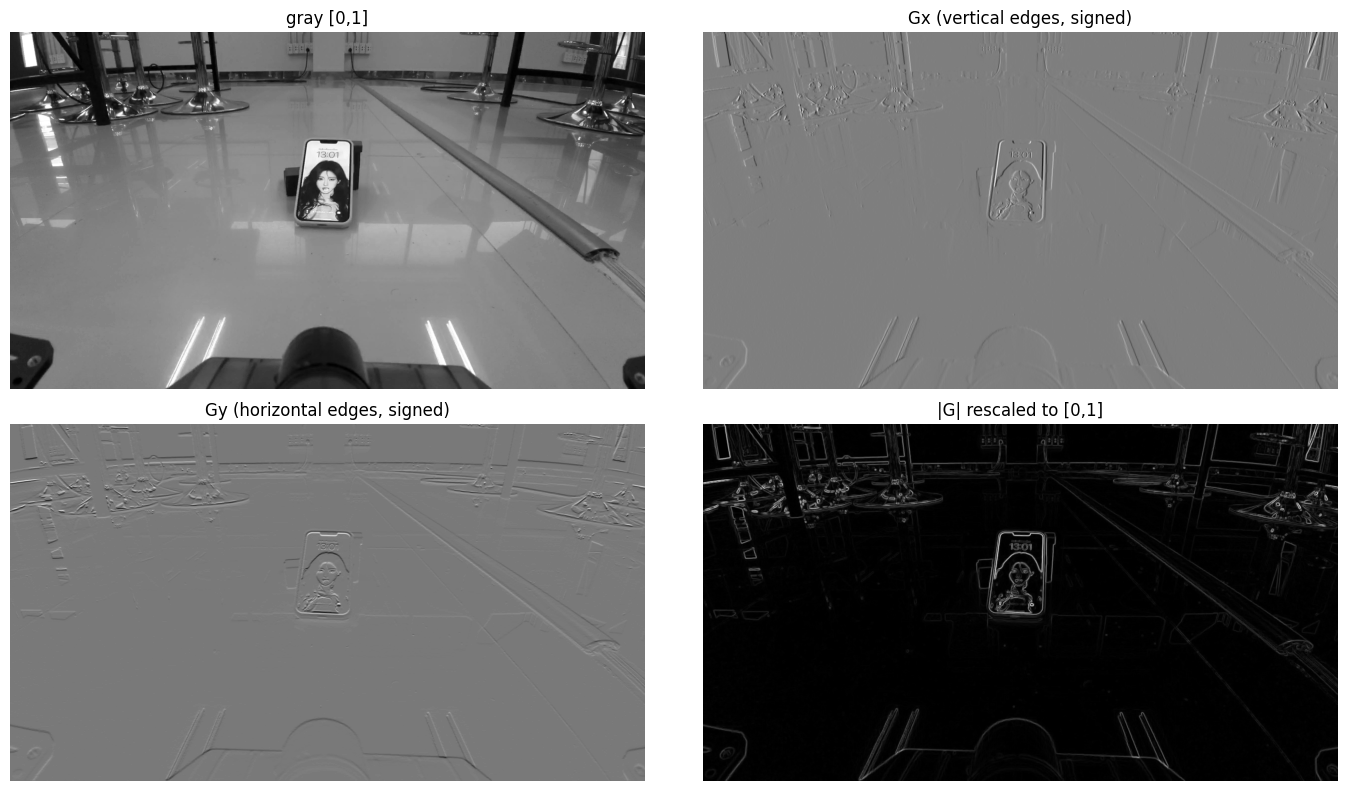

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax[0, 0].imshow(gray01, cmap="gray", vmin=0, vmax=1)
ax[0, 0].set_title("gray [0,1]")
ax[0, 1].imshow(Gx, cmap="gray")
ax[0, 1].set_title("Gx (vertical edges, signed)")
ax[1, 0].imshow(Gy, cmap="gray")
ax[1, 0].set_title("Gy (horizontal edges, signed)")
ax[1, 1].imshow(G01, cmap="gray", vmin=0, vmax=1)
ax[1, 1].set_title("|G| rescaled to [0,1]")
for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

### อ่านภาพ section 5

- **Gx** สว่าง/มืดตรงขอบแนวตั้ง (ข้างโทรศัพท์ ขาโต๊ะ) ค่ามี + และ − ตามว่าด้านไหนสว่างกว่า ส่วนพื้นที่เรียบเป็นสีเทากลาง (= 0)
- **Gy** ตรงข้ามกัน จับขอบแนวนอน (ขอบบนล่างของโทรศัพท์)
- **|G|** รวมสองทิศด้วย √(Gx² + Gy²) ได้ "ขอบแรงแค่ไหน" ไม่สนทิศ แล้ว rescale เป็น [0,1]: พื้นเรียบดำ ขอบสว่าง
- ภาพ |G| ดูมืดเพราะ rescale ยึดขอบที่แรงที่สุดในภาพ (เช่น แสงสะท้อนบนพื้น) เป็น 1 ขอบส่วนใหญ่อ่อนกว่าจึงจาง
- Gx, Gy ที่ได้ตรงกับ `cv2.Sobel` (เช็กในเซลล์ก่อนหน้า)

## 6. Box Blur (สไลด์ 64)

เทียบ kernel 3×3 สองแบบบนภาพ grayscale [0,1] (ก่อน/หลัง)

- **kernel 1:** ทุกช่องเป็น 1 (ผลรวม = 9) ภาพสว่างขึ้น ~9 เท่า ส่วนที่เกิน 1 จะถูก clip ตอนแสดง
- **kernel 1/9:** ทุกช่องเป็น 1/9 (ผลรวม = 1, normalized) ความสว่างคงเดิม แค่เบลอ
- same padding (replicate) p = 1 เพื่อ **ล็อก output ให้ขนาดเท่า input** พิกเซลพิกัดเดียวกันจึงเทียบกันตรงๆ ได้

**API ที่ใช้ **

| ขั้นตอน | API |
|---|---|
| สร้าง kernel (สร้างเอง) | `np.ones`, หารด้วย `m*m` |
| เติมขอบ (same padding) | `cv2.copyMakeBorder(..., cv2.BORDER_REPLICATE)` |
| Convolution | `cv2.filter2D(..., cv2.CV_32F, kernel)` |
| ตัดขอบที่ cv2 เติมเอง | NumPy slicing `[r:-r, r:-r]` |
| ตรวจความถูกต้อง | `cv2.blur(..., borderType=cv2.BORDER_REPLICATE)` |

In [16]:
# สร้าง kernel เอง ด้วย NumPy (สไลด์ 64)
K_ones = np.ones((m, m), dtype=np.float32)   # kernel 1     : ผลรวม = 9 (ไม่ normalize)
K_norm = K_ones / (m * m)                    # kernel 1/9   : ผลรวม = 1 (normalize)

print("K_ones =\n", K_ones, "\nsum =", K_ones.sum())
print("K_norm =\n", K_norm, "\nsum =", K_norm.sum())

K_ones =
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]] 
sum = 9.0
K_norm =
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]] 
sum = 1.0


In [17]:
# Box blur เป็น convolution เหมือนเดิม: kernel สมมาตร (ทุกค่าเท่ากัน) พลิก 180 องศาแล้วเหมือนเดิม
# จึงส่งเข้า API ได้ตรงๆ ไม่ต้อง np.flip
# API: cv2.copyMakeBorder(BORDER_REPLICATE) -> cv2.filter2D -> ตัดขอบ (อยู่ใน conv_replicate_pad)
# same padding p=1 -> ล็อก output ให้ขนาดเท่า input
_, blur_ones = conv_replicate_pad(gray01, K_ones, 1)
_, blur_norm = conv_replicate_pad(gray01, K_norm, 1)

print("input  size:", gray01.shape)
print("kernel 1   output size:", blur_ones.shape)
print("kernel 1/9 output size:", blur_norm.shape)
print()
print(f"mean  input: {gray01.mean():.4f} | kernel 1: {blur_ones.mean():.4f} | kernel 1/9: {blur_norm.mean():.4f}")
print(f"max   input: {gray01.max():.4f} | kernel 1: {blur_ones.max():.4f} | kernel 1/9: {blur_norm.max():.4f}")
print(f"สัดส่วน kernel 1 / kernel 1/9 (ค่าเฉลี่ย): {blur_ones.mean() / blur_norm.mean():.3f}")
print("blur_ones / 9 == blur_norm :", np.allclose(blur_ones / 9, blur_norm, atol=1e-5))

# ตรวจกับ API สำเร็จรูป cv2.blur (normalized box filter 3x3)
ref = cv2.blur(gray01, (m, m), borderType=cv2.BORDER_REPLICATE)
print("ตรงกับ cv2.blur           :", np.allclose(blur_norm, ref, atol=1e-5))

input  size: (720, 1280)
kernel 1   output size: (720, 1280)
kernel 1/9 output size: (720, 1280)

mean  input: 0.4584 | kernel 1: 4.1258 | kernel 1/9: 0.4584
max   input: 1.0000 | kernel 1: 9.0000 | kernel 1/9: 1.0000
สัดส่วน kernel 1 / kernel 1/9 (ค่าเฉลี่ย): 9.000
blur_ones / 9 == blur_norm : True
ตรงกับ cv2.blur           : True


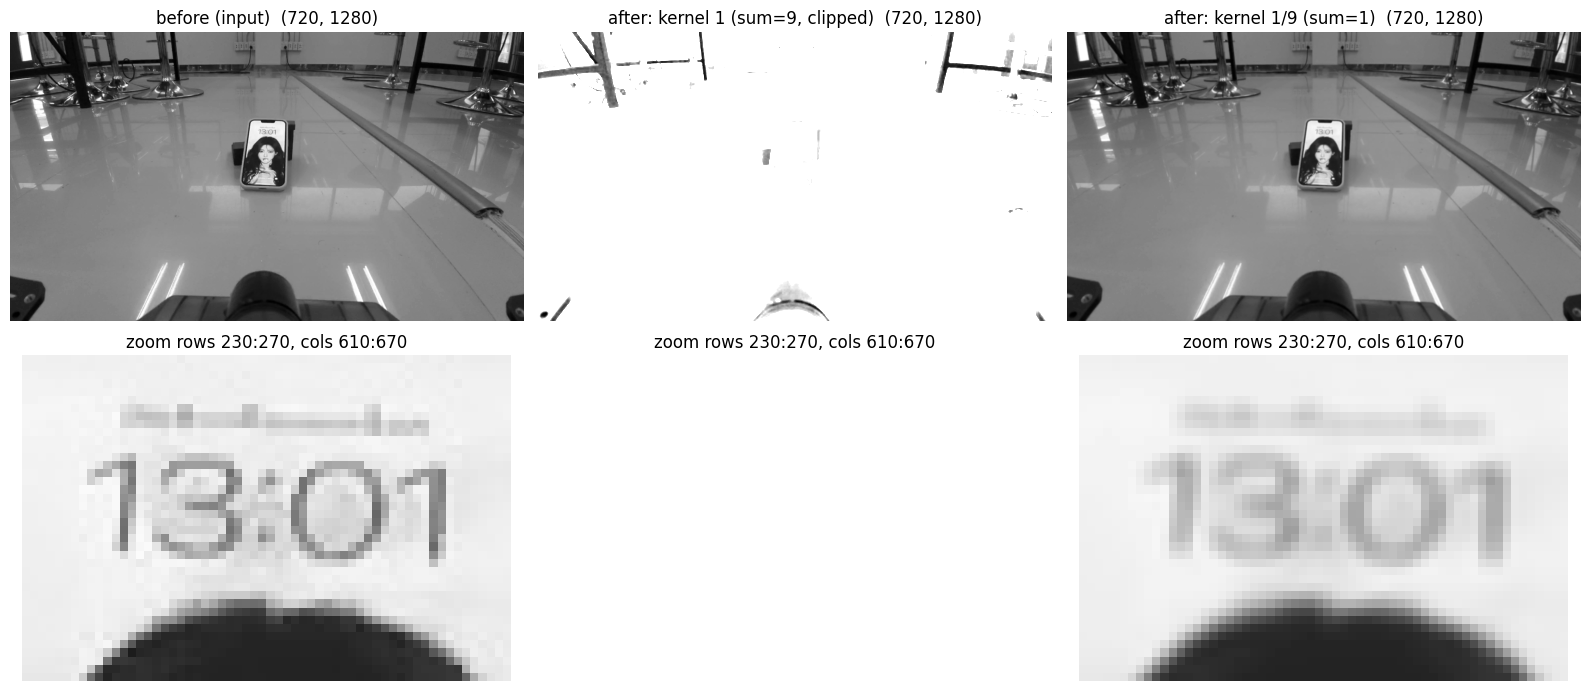

pixel [245,640]  before: 0.5804 | kernel 1: 7.0235 | kernel 1/9: 0.7804
ค่าเฉลี่ยต่างจาก input (|after - before|) kernel 1/9: 0.005726238


In [18]:
names = ["before (input)", "after: kernel 1 (sum=9, clipped)", "after: kernel 1/9 (sum=1)"]
imgs = [gray01, blur_ones, blur_norm]

# zoom บริเวณตัวเลขนาฬิกาบนจอโทรศัพท์ เพื่อเห็นความเบลอ (pixel พิกัดเดียวกันทุกภาพ)
R0, R1, C0, C1 = 230, 270, 610, 670

fig, ax = plt.subplots(2, 3, figsize=(16, 7))
for j, (name, im) in enumerate(zip(names, imgs)):
    ax[0, j].imshow(im, cmap="gray", vmin=0, vmax=1)
    ax[0, j].set_title(f"{name}  {im.shape}")
    ax[1, j].imshow(im[R0:R1, C0:C1], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax[1, j].set_title(f"zoom rows {R0}:{R1}, cols {C0}:{C1}")
    ax[0, j].axis("off")
    ax[1, j].axis("off")
plt.tight_layout()
plt.show()

# pixel พิกัดเดียวกัน ก่อน/หลัง (เทียบได้เพราะ output ขนาดเท่า input)
r, c = 245, 640
print(f"pixel [{r},{c}]  before: {gray01[r, c]:.4f} | kernel 1: {blur_ones[r, c]:.4f} | kernel 1/9: {blur_norm[r, c]:.4f}")
print("ค่าเฉลี่ยต่างจาก input (|after - before|) kernel 1/9:", np.abs(blur_norm - gray01).mean())

### อ่านผล section 6 (Box blur)

- **kernel 1** (ผลรวม = 9): ค่าที่ได้เป็น 9 เท่าของ kernel 1/9 พอดี (สูงสุด 9.0) ตอนแสดงที่ช่วง 0–1 จึงเกินแล้วถูก clip เป็นขาวเกือบทั้งภาพ
- **kernel 1/9** (ผลรวม = 1): ความสว่างเฉลี่ยเท่า input แค่เบลอ ตัวเลข "13:01" ในภาพซูมนุ่มลง
- บทเรียน: kernel สำหรับเบลอ **ผลรวมต้อง = 1** (normalize) ไม่งั้นความสว่างเปลี่ยน
- ล็อก output ด้วย same padding ให้เท่า input → pixel พิกัดเดียวกันเทียบก่อน/หลังตรงๆ ได้ (ตัวอย่างที่ [245, 640] ที่พิมพ์ไว้ด้านบน)

## 7. Gaussian Blur (สไลด์ 65)

Gaussian kernel ให้น้ำหนัก **พิกเซลตรงกลางมากที่สุด** และลดลงตามระยะห่างเป็นรูประฆัง ต่างจาก box blur ที่ทุกช่องน้ำหนักเท่ากัน

1. สร้าง kernel 3×3 (1/16) และ 5×5 (1/256) เอง จากแถว Pascal [1 2 1] และ [1 4 6 4 1] (binomial ที่ประมาณ Gaussian) แล้วทำ outer product
2. พล็อต Gaussian ก่อนใช้: เส้นโค้ง 1D, พื้นผิว 2D และค่าใน kernel 5×5
3. Convolve ด้วย same padding (ล็อก output ให้ขนาดเท่า input) แล้วเทียบก่อน/หลัง

kernel ใหญ่ขึ้นเฉลี่ยจากพิกเซลมากขึ้น จึงเบลอมากกว่า

**API ที่ใช้**

| ขั้นตอน | API |
|---|---|
| สร้าง kernel (สร้างเอง) | `np.convolve` (สร้างแถว Pascal), `np.outer` (2D จาก 1D), หารผลรวมให้ = 1 |
| เติมขอบ (same padding) | `cv2.copyMakeBorder(..., cv2.BORDER_REPLICATE)` |
| Convolution | `cv2.filter2D(..., cv2.CV_32F, kernel)` |
| ตัดขอบที่ cv2 เติมเอง | NumPy slicing `[r:-r, r:-r]` |
| พล็อตกราฟ | `plt.plot`, `plt.stem`, `plot_surface`, `imshow` |
| ตรวจความถูกต้อง | `cv2.GaussianBlur(..., borderType=cv2.BORDER_REPLICATE)` |

In [19]:
# สร้าง Gaussian kernel เอง (binomial approximation ตามสไลด์ 65) ด้วย NumPy
def binomial_row(n):
    """แถวของ Pascal's triangle ยาว n ช่อง เช่น n=5 -> [1 4 6 4 1] (สร้างจาก np.convolve([1,1]) ซ้ำ)"""
    row = np.array([1.0])
    for _ in range(n - 1):
        row = np.convolve(row, [1.0, 1.0])
    return row

m3, m5 = 3, 5
b3, b5 = binomial_row(m3), binomial_row(m5)          # [1 2 1] และ [1 4 6 4 1]

# 2D Gaussian = outer product ของ 1D กับตัวเอง (แยกแกนได้: g(x,y) = g(x) * g(y))
K_g3 = (np.outer(b3, b3) / np.outer(b3, b3).sum()).astype(np.float32)   # 1/16 * [[1 2 1],[2 4 2],[1 2 1]]
K_g5 = (np.outer(b5, b5) / np.outer(b5, b5).sum()).astype(np.float32)   # 1/256 * [[1 4 6 4 1],...]

print("b3 =", b3, "| b5 =", b5)
print("K_g3 x 16 =\n", np.round(K_g3 * 16).astype(int), "\n sum =", K_g3.sum())
print("K_g5 x 256 =\n", np.round(K_g5 * 256).astype(int), "\n sum =", K_g5.sum())

b3 = [1. 2. 1.] | b5 = [1. 4. 6. 4. 1.]
K_g3 x 16 =
 [[1 2 1]
 [2 4 2]
 [1 2 1]] 
 sum = 1.0
K_g5 x 256 =
 [[ 1  4  6  4  1]
 [ 4 16 24 16  4]
 [ 6 24 36 24  6]
 [ 4 16 24 16  4]
 [ 1  4  6  4  1]] 
 sum = 1.0


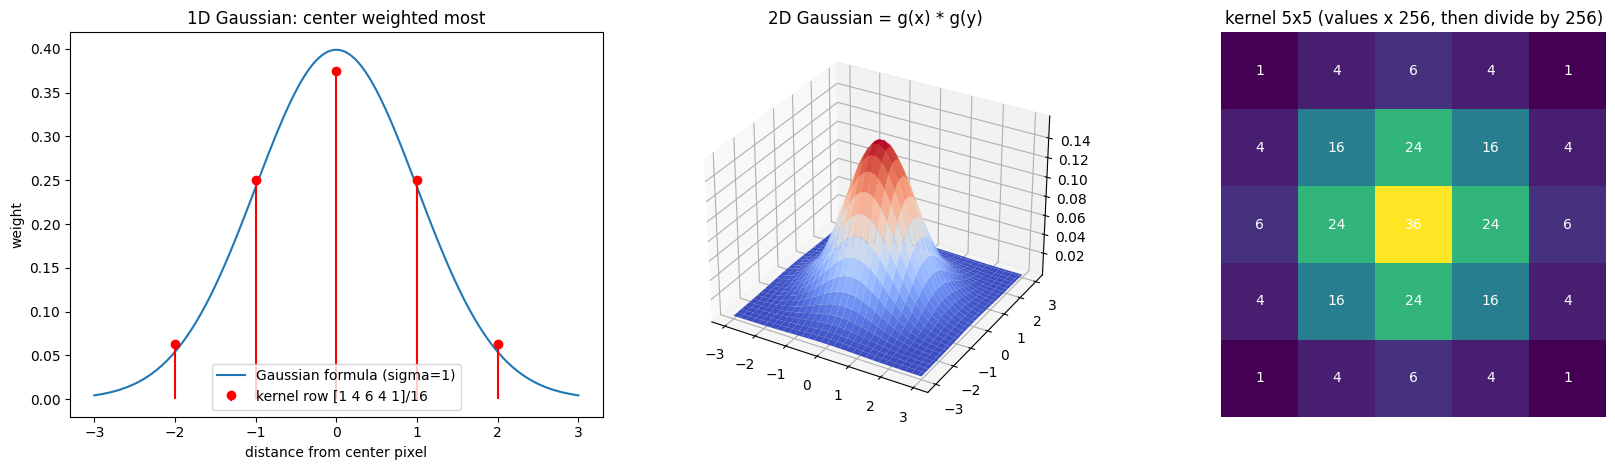

In [20]:
# กราฟ Gaussian ก่อนนำ kernel ไปใช้: (1) เส้นโค้ง 1D  (2) พื้นผิว 2D  (3) ค่าใน kernel 5x5
sigma = 1.0   # binomial [1 4 6 4 1] ใกล้เคียง Gaussian ที่ sigma = 1.0

def gauss1d(x, sigma, mu=0.0):
    return np.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) / np.sqrt(2 * np.pi * sigma ** 2)

x = np.linspace(-3, 3, 200)
xs = np.arange(-2, 3)                       # ตำแหน่งของแต่ละช่องใน kernel 5 ช่อง

fig = plt.figure(figsize=(17, 4.8))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(x, gauss1d(x, sigma), label="Gaussian formula (sigma=1)")
ax1.stem(xs, b5 / b5.sum(), linefmt="r-", markerfmt="ro", basefmt=" ", label="kernel row [1 4 6 4 1]/16")
ax1.set_title("1D Gaussian: center weighted most")
ax1.set_xlabel("distance from center pixel")
ax1.set_ylabel("weight")
ax1.legend()

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
g = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(g, g)
ax2.plot_surface(X, Y, gauss1d(X, sigma) * gauss1d(Y, sigma), cmap="coolwarm")
ax2.set_title("2D Gaussian = g(x) * g(y)")

ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(K_g5, cmap="viridis")
for i in range(m5):
    for j in range(m5):
        ax3.text(j, i, int(round(K_g5[i, j] * 256)), ha="center", va="center", color="w")
ax3.set_title("kernel 5x5 (values x 256, then divide by 256)")
ax3.axis("off")
plt.tight_layout()
plt.show()

In [21]:
# Gaussian kernel สมมาตร -> พลิก 180 องศาแล้วเหมือนเดิม ส่งเข้า API ได้ตรงๆ
# API: cv2.copyMakeBorder(BORDER_REPLICATE) -> cv2.filter2D -> ตัดขอบ (อยู่ใน conv_replicate_pad)
# same padding: p = (ขนาด kernel // 2) -> 3x3 ใช้ p=1, 5x5 ใช้ p=2 เพื่อให้ output ขนาดเท่า input
_, gauss3 = conv_replicate_pad(gray01, K_g3, 1)
_, gauss5 = conv_replicate_pad(gray01, K_g5, 2)

print("input size          :", gray01.shape)
print("Gaussian 3x3 output :", gauss3.shape)
print("Gaussian 5x5 output :", gauss5.shape)

# ตรวจกับ API สำเร็จรูป cv2.GaussianBlur (sigma=1.0)
# ไม่เท่ากันเป๊ะ เพราะ kernel ในสไลด์เป็น binomial ที่ประมาณ Gaussian ส่วน cv2 คำนวณจากสูตร Gaussian จริง
ref5 = cv2.GaussianBlur(gray01, (5, 5), sigmaX=1.0, borderType=cv2.BORDER_REPLICATE)
d = np.abs(gauss5 - ref5)
print(f"เทียบ cv2.GaussianBlur 5x5 (sigma=1): max diff = {d.max():.5f}, mean diff = {d.mean():.6f}")

input size          : (720, 1280)
Gaussian 3x3 output : (720, 1280)
Gaussian 5x5 output : (720, 1280)
เทียบ cv2.GaussianBlur 5x5 (sigma=1): max diff = 0.02227, mean diff = 0.000350


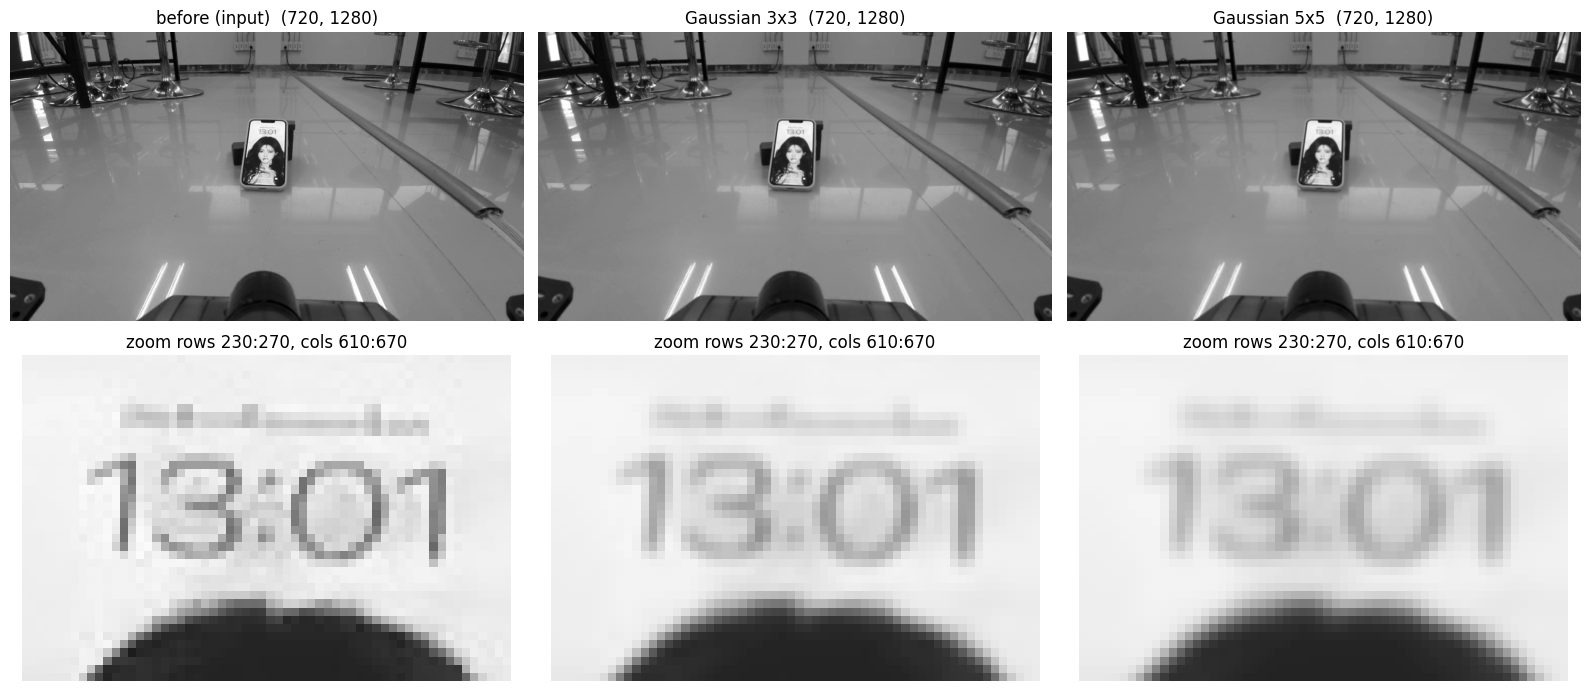

Gaussian 3x3     mean|after - before| = 0.00444
Gaussian 5x5     mean|after - before| = 0.00634
Box 5x5 (1/25)   mean|after - before| = 0.00978


In [22]:
names = ["before (input)", "Gaussian 3x3", "Gaussian 5x5"]
imgs = [gray01, gauss3, gauss5]

# zoom บริเวณเดิม (ตัวเลขนาฬิกาบนจอโทรศัพท์) เพื่อเทียบความเบลอ
R0, R1, C0, C1 = 230, 270, 610, 670

fig, ax = plt.subplots(2, 3, figsize=(16, 7))
for j, (name, im) in enumerate(zip(names, imgs)):
    ax[0, j].imshow(im, cmap="gray", vmin=0, vmax=1)
    ax[0, j].set_title(f"{name}  {im.shape}")
    ax[1, j].imshow(im[R0:R1, C0:C1], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax[1, j].set_title(f"zoom rows {R0}:{R1}, cols {C0}:{C1}")
    ax[0, j].axis("off")
    ax[1, j].axis("off")
plt.tight_layout()
plt.show()

# วัดว่าเบลอมากน้อยแค่ไหน: ค่าเฉลี่ย |after - before| (ยิ่งมาก = ภาพเปลี่ยนจากเดิมมาก = เบลอมาก)
_, box5 = conv_replicate_pad(gray01, np.ones((5, 5), np.float32) / 25, 2)   # box 5x5 เอาไว้เทียบ
for name, im in [("Gaussian 3x3", gauss3), ("Gaussian 5x5", gauss5), ("Box 5x5 (1/25)", box5)]:
    print(f"{name:16s} mean|after - before| = {np.abs(im - gray01).mean():.5f}")

### อ่านผล section 7 (Gaussian blur)

**อ่านกราฟก่อนใช้**
- 1D: เส้นโค้งระฆังจากสูตร Gaussian (σ = 1) จุดแดงคือน้ำหนักจริงของแถว `[1 4 6 4 1]/16` อยู่บนเส้นโค้งพอดี → kernel คือการ "สุ่มค่า" จาก Gaussian 5 ตำแหน่ง
- 2D: พื้นผิวภูเขา = g(x)·g(y) ยอดอยู่ตรงกลาง (นี่คือเหตุผลที่สร้างด้วย `np.outer`)
- heatmap 5×5: ตรงกลาง 36 มากสุด ลดลงไปมุมเป็น 1 → พิกเซลใกล้ศูนย์กลางมีอิทธิพลมากกว่า

**อ่านผล**
- 5×5 เบลอมากกว่า 3×3 เพราะเฉลี่ยจาก 25 พิกเซลแทน 9 (ค่า mean |after − before| 0.0063 เทียบกับ 0.0044)
- แต่เบลอน้อยกว่า **box 5×5** (0.0098) เพราะ Gaussian ให้น้ำหนักตรงกลางมากกว่ารอบนอก ขณะที่ box ให้ทุกช่องเท่ากัน

## 8. Median Filter (สไลด์ 66)

**Median filter ไม่ใช่การเฉลี่ย** เลื่อนหน้าต่าง 5×5 ไปทีละพิกเซล เอา 25 ค่าในหน้าต่างมา **sort แล้วเลือกตัวกลาง** ไปแทนพิกเซลตรงกลาง

- ตัวอย่าง `[10, 10, 10, 10, 255]`: เฉลี่ย = 59 (โดนจุดขาวลาก) แต่ median = 10 (จุดผิดปกติไม่มีผล)
- ใช้กับ **Salt & Pepper noise** (จุดขาว/ดำสุ่ม) เลยสร้าง noise 5% ใส่ภาพก่อน แล้วเทียบกับ Gaussian 5×5
- ไม่ใช่ convolution (ไม่มีน้ำหนักคูณ ไม่เป็นเชิงเส้น) "kernel 5×5" จึงเป็นแค่ขนาดหน้าต่าง
- same padding (replicate) ให้ output ขนาดเท่า input

**API ที่ใช้**

| ขั้นตอน | API |
|---|---|
| สร้าง noise | `np.random.default_rng`, boolean mask |
| เติมขอบ (same padding) | `cv2.copyMakeBorder(..., cv2.BORDER_REPLICATE)` |
| Median (เขียนเอง) | `np.stack` (ซ้อน 25 ตำแหน่งเลื่อน), `np.sort`, เลือก index กลาง |
| ตรวจความถูกต้อง | `cv2.medianBlur(img, 5)` |
| Gaussian เทียบ | `cv2.copyMakeBorder` + `cv2.filter2D` (เหมือน section 7) |

In [23]:
# สร้าง Salt & Pepper noise: สุ่มเลือกพิกเซล 5% ทำเป็นดำ (pepper 2.5%) หรือขาว (salt 2.5%)
rng = np.random.default_rng(0)                 # seed คงที่ ผลซ้ำได้
DENSITY = 0.05
u = rng.random(gray01.shape)   # ค่าสุ่ม 0-1 ต่อพิกเซล
noisy = gray01.copy()
noisy[u < DENSITY / 2] = 0.0                   # pepper (จุดดำ)
noisy[u > 1 - DENSITY / 2] = 1.0               # salt (จุดขาว)

print("พิกเซลที่ถูกทำ noise:", np.count_nonzero(noisy != gray01), "จาก", gray01.size,
      f"({np.count_nonzero(noisy != gray01) / gray01.size:.2%})")

พิกเซลที่ถูกทำ noise: 46247 จาก 921600 (5.02%)


In [24]:
import time   # import ไว้แล้วใน section 3 ใส่ซ้ำเพื่อให้รันเซลล์นี้แยกได้

def median_filter(img, k):
    """Median filter เขียนเอง: ทุกพิกเซลเอา k*k ค่าในหน้าต่างมา sort แล้วเลือกตัวกลาง"""
    p = k // 2
    padded = cv2.copyMakeBorder(img, p, p, p, p, cv2.BORDER_REPLICATE)   # same padding
    h, w = img.shape
    # เลื่อนหน้าต่างครบ k*k ตำแหน่ง -> ได้ k*k ภาพซ้อนกัน (แต่ละชั้นคือ "เพื่อนบ้านตำแหน่งที่ i,j" ของทุกพิกเซล)
    stack = np.stack([padded[i:i + h, j:j + w] for i in range(k) for j in range(k)], axis=0)
    stack_sorted = np.sort(stack, axis=0)        # sort ค่าของแต่ละพิกเซลตามแกนชั้น
    return stack_sorted[(k * k) // 2]            # ตัวกลาง: index 12 จาก 25 ค่า (0..24)


t0 = time.perf_counter()
med5 = median_filter(noisy, 5)
t_own = time.perf_counter() - t0

t0 = time.perf_counter()
med5_cv = cv2.medianBlur(noisy, 5)               # API สำเร็จรูป (ขอบเป็นแบบ replicate)
t_cv = time.perf_counter() - t0

print("input size :", noisy.shape)
print("median 5x5 :", med5.shape)
print("ตรงกับ cv2.medianBlur เป๊ะ:", np.array_equal(med5, med5_cv))
print(f"เวลา เขียนเอง (sort) : {t_own:.4f} s | cv2.medianBlur : {t_cv:.4f} s")

# เทียบ: Gaussian 5x5 บนภาพที่มี noise (เฉลี่ยจุดขาว/ดำเข้ามา จึงเบลอแต่ไม่หายไป)
_, gauss5_noisy = conv_replicate_pad(noisy, K_g5, 2)

input size : (720, 1280)
median 5x5 : (720, 1280)
ตรงกับ cv2.medianBlur เป๊ะ: True
เวลา เขียนเอง (sort) : 0.5801 s | cv2.medianBlur : 0.0347 s


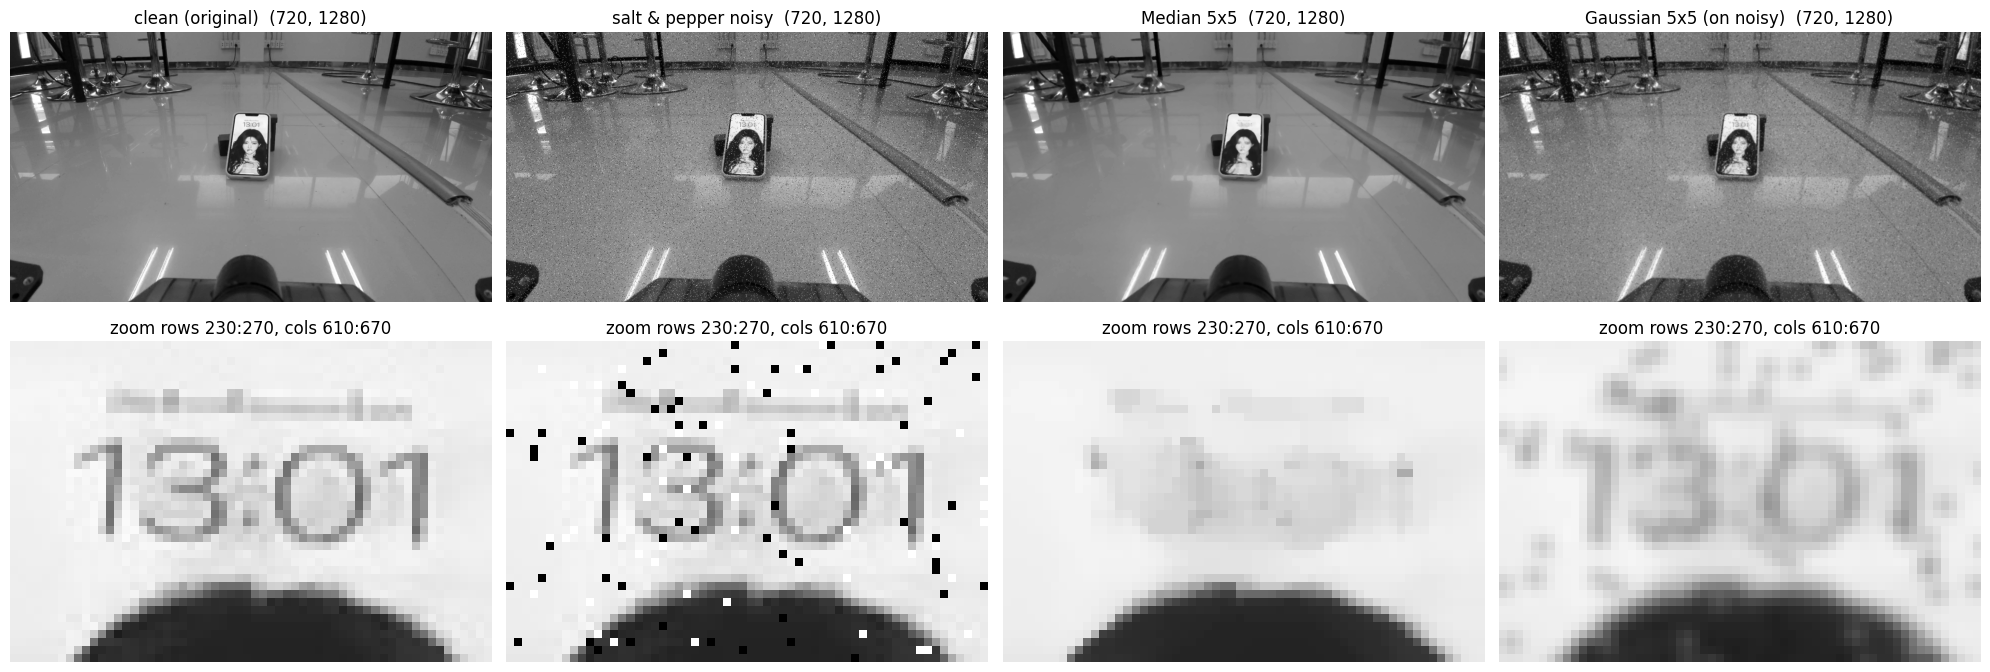

noisy (ยังไม่กรอง)   mean|x - clean| = 0.02508
Median 5x5           mean|x - clean| = 0.00638
Gaussian 5x5         mean|x - clean| = 0.02387


In [25]:
names = ["clean (original)", "salt & pepper noisy", "Median 5x5", "Gaussian 5x5 (on noisy)"]
imgs = [gray01, noisy, med5, gauss5_noisy]

# zoom บริเวณเดิม (ตัวเลขนาฬิกา) เพื่อดูว่า noise หายไปไหม
R0, R1, C0, C1 = 230, 270, 610, 670

fig, ax = plt.subplots(2, 4, figsize=(20, 7))
for j, (name, im) in enumerate(zip(names, imgs)):
    ax[0, j].imshow(im, cmap="gray", vmin=0, vmax=1)
    ax[0, j].set_title(f"{name}  {im.shape}")
    ax[1, j].imshow(im[R0:R1, C0:C1], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax[1, j].set_title(f"zoom rows {R0}:{R1}, cols {C0}:{C1}")
    ax[0, j].axis("off")
    ax[1, j].axis("off")
plt.tight_layout()
plt.show()

# ยิ่งใกล้ภาพ clean ยิ่งดี: ค่าเฉลี่ย |ผลลัพธ์ - clean|
for name, im in [("noisy (ยังไม่กรอง)", noisy), ("Median 5x5", med5), ("Gaussian 5x5", gauss5_noisy)]:
    print(f"{name:20s} mean|x - clean| = {np.abs(im - gray01).mean():.5f}")

### อ่านผล section 8 (Median filter)

- ภาพที่มี noise: จุดขาว/ดำสุ่ม 5% ของพิกเซล
- **Median 5×5** ลบจุดเหล่านั้นหายเกือบหมด (ความคลาดเคลื่อนจากภาพ clean ลดจาก ~0.025 เหลือ ~0.006)
- **Gaussian 5×5** แทบไม่ช่วย (~0.024) เพราะเฉลี่ยจุดขาว/ดำเข้าไปด้วย จุดจึงกลายเป็นก้อนเทาเบลอๆ แทนที่จะหาย
- **ข้อสังเกต:** median 5×5 ทำให้เส้นบางๆ ของตัวเลข "13:01" **จางหาย** เพราะเส้นหนาราว 2 พิกเซล น้อยกว่าครึ่งหน้าต่าง (5 พิกเซล) median จึงมองเป็นจุดผิดปกติแล้วตัดทิ้งเหมือน noise → หน้าต่างใหญ่กรอง noise ได้ดีแต่ทำลายรายละเอียดเล็ก
- ที่เขียนเอง (sort) ช้ากว่า `cv2.medianBlur` มาก เพราะ NumPy ต้อง sort 25 ชั้นทุกพิกเซล ส่วน OpenCV ใช้อัลกอริทึมเฉพาะทาง ผลลัพธ์ตรงกันเป๊ะ

## สรุป API ที่ใช้

| Section | ขั้นตอน | API |
|---|---|---|
| ทั้งหมด | โหลดรูป / แปลงสี | `cv2.imread`, `cv2.cvtColor` (BGR→RGB, BGR→GRAY) |
| 1–2 | Convolution | `cv2.filter2D(gray, cv2.CV_32F, kernel_flipped)` (พลิก kernel เองด้วย `np.flip`) |
| 1–2 | สร้าง kernel 1–9 | `np.arange(...).reshape(3, 3)` |
| 2 | No padding | NumPy slicing `[r:-r, r:-r]` ตัดขอบที่ cv2 เติมเอง |
| 3 | Zero padding | `cv2.copyMakeBorder(..., cv2.BORDER_CONSTANT, value=0)` + `cv2.filter2D` |
| 3 | kernel สุ่ม | `np.random.default_rng(42).random(...)` แล้วหารผลรวม |
| 3–4 | วัดเวลา | `time.perf_counter()` |
| 4 | Same padding | `cv2.copyMakeBorder(..., cv2.BORDER_REPLICATE)` + `cv2.filter2D` |
| 5 | Sobel | kernel สร้างเอง (`np.array`) + `cv2.filter2D` ตรวจกับ `cv2.Sobel` |
| 5 | Magnitude / rescale | `np.sqrt`, min-max ด้วย NumPy |
| 6 | Box blur | `np.ones` + `cv2.filter2D` ตรวจกับ `cv2.blur` |
| 7 | Gaussian | `np.convolve` (แถว Pascal), `np.outer` + `cv2.filter2D` ตรวจกับ `cv2.GaussianBlur` |
| 8 | Median (เขียนเอง) | `np.stack`, `np.sort` ตรวจกับ `cv2.medianBlur` |
| 8 | Salt & pepper noise | `np.random.default_rng(0).random(...)` + boolean mask |
| กราฟ | แสดงผล | `plt.imshow`, `plt.plot`, `plt.stem`, `plot_surface` |

**หมายเหตุ:** median filter ไม่ใช่ convolution (ไม่มีน้ำหนักคูณ ไม่เป็นเชิงเส้น) ส่วน convolution ทุก section ใช้ `cv2.filter2D` เป็น API หลัก